In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import pandas_datareader as data 

plt.style.use('fivethirtyeight')
%matplotlib inline

In [2]:
!pip install pandas-datareader


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import yfinance as yf
import datetime as dt
import pandas as pd

stock = "POWERGRID.NS"
start = dt.datetime(2005, 1, 1)
end = dt.datetime(2026, 11, 1)

df = yf.download(stock, start=start, end=end)

# Flatten MultiIndex columns if present (new yfinance versions return MultiIndex)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.droplevel(1)

if df.empty:
    raise ValueError("No data downloaded! Please check your internet connection or update yfinance (pip install --upgrade yfinance).")
else:
    print("Data downloaded successfully:", df.shape)


[*********************100%***********************]  1 of 1 completed

Data downloaded successfully: (4555, 5)


In [4]:
df.head

<bound method NDFrame.head of Price            Close        High         Low        Open     Volume
Date                                                                 
2007-10-05   30.896227   33.629592   25.536990   27.579336  855215656
2007-10-08   29.314564   31.940436   29.130291   31.940436  126671715
2007-10-09   31.310856   31.587263   27.748267   29.329932  116725709
2007-10-10   31.602608   32.247560   31.326201   32.124711   67931378
2007-10-11   35.134491   36.854362   31.326209   36.854362  106320954
...                ...         ...         ...         ...        ...
2026-03-19  296.700012  300.500000  295.950012  297.649994    8594078
2026-03-20  297.600006  305.000000  296.600006  300.100006   28392470
2026-03-23  302.100006  304.350006  293.100006  298.000000   23771660
2026-03-24  299.000000  309.000000  292.399994  309.000000   24123621
2026-03-25  297.250000  302.250000  296.600006  299.899994    9470693

[4555 rows x 5 columns]>

In [5]:
df.shape

(4555, 5)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4555 entries, 2007-10-05 to 2026-03-25
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   4555 non-null   float64
 1   High    4555 non-null   float64
 2   Low     4555 non-null   float64
 3   Open    4555 non-null   float64
 4   Volume  4555 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 213.5 KB


In [7]:
df.isnull().sum()

Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [8]:
df.describe()

Price,Close,High,Low,Open,Volume
count,4555.000000,4555.000000,4555.000000,4555.000000,4.555000e+03
mean,91.767988,92.917677,90.633281,91.809647,1.197884e+07
std,80.796638,81.689900,79.876940,80.801144,1.990919e+07
min,18.038851,19.282909,16.172763,19.189604,0.000000e+00
25%,35.249174,35.784349,34.754779,35.299934,5.017511e+06
50%,65.216995,66.187622,64.428434,65.353919,8.673501e+06
75%,102.363579,103.682626,101.413377,102.684967,1.389033e+07
max,344.843262,345.598106,337.058457,343.522181,8.552157e+08


In [9]:
df = df.reset_index()

In [10]:
df.shape

(4555, 6)

In [11]:
df.columns

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')

In [12]:
df.to_csv("powergrid.csv")

In [13]:
data01 = pd.read_csv("powergrid.csv")

In [14]:
data01.head()

,Unnamed: 0,Date,Close,High,Low,Open,Volume
0,0,2007-10-05,30.896227,33.629592,25.536990,27.579336,855215656
1,1,2007-10-08,29.314564,31.940436,29.130291,31.940436,126671715
2,2,2007-10-09,31.310856,31.587263,27.748267,29.329932,116725709
3,3,2007-10-10,31.602608,32.247560,31.326201,32.124711,67931378
4,4,2007-10-11,35.134491,36.854362,31.326209,36.854362,106320954


In [15]:
!pip install plotly



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
print(data01.columns)


Index(['Unnamed: 0', 'Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')


In [17]:
#Candlesticks

import plotly.graph_objects as go

fig = go.Figure(data=[go.Candlestick(
    x=data01.index,
    open=data01['Open'],
    high=data01['High'],
    low=data01['Low'],
    close=data01['Close']
)])

fig.update_layout(xaxis_rangeslider_visible=False)
fig.show()

In [18]:
df.head()

Price,Date,Close,High,Low,Open,Volume
0,2007-10-05,30.896227,33.629592,25.536990,27.579336,855215656
1,2007-10-08,29.314564,31.940436,29.130291,31.940436,126671715
2,2007-10-09,31.310856,31.587263,27.748267,29.329932,116725709
3,2007-10-10,31.602608,32.247560,31.326201,32.124711,67931378
4,2007-10-11,35.134491,36.854362,31.326209,36.854362,106320954


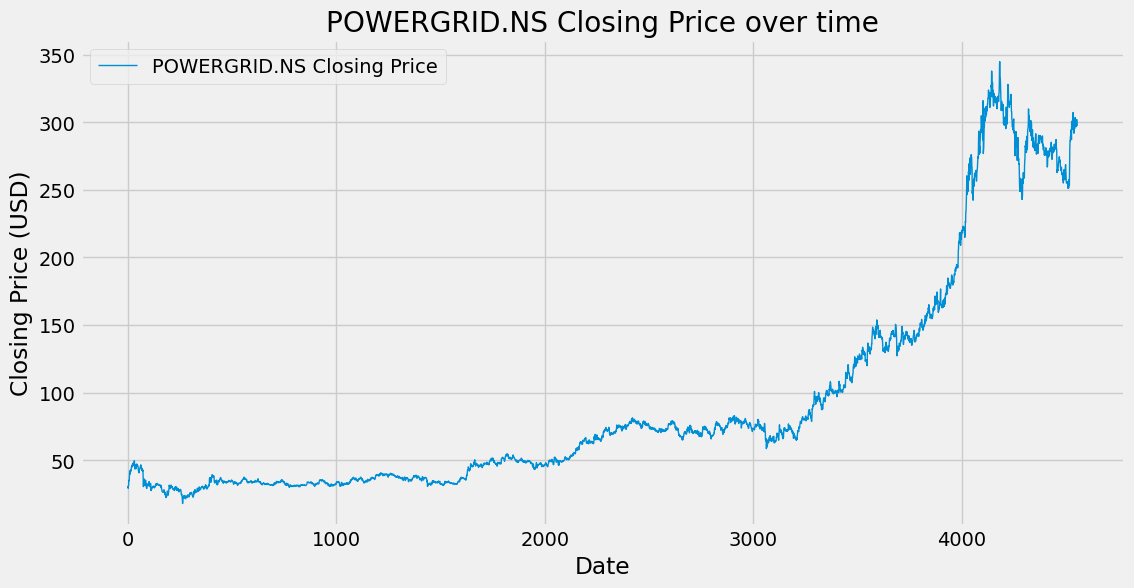

In [19]:
plt.figure(figsize=(12, 6))
plt.plot(df['Close'], label = f'{stock} Closing Price', linewidth = 1)
plt.title(f'{stock} Closing Price over time')
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')
plt.legend()
plt.show()

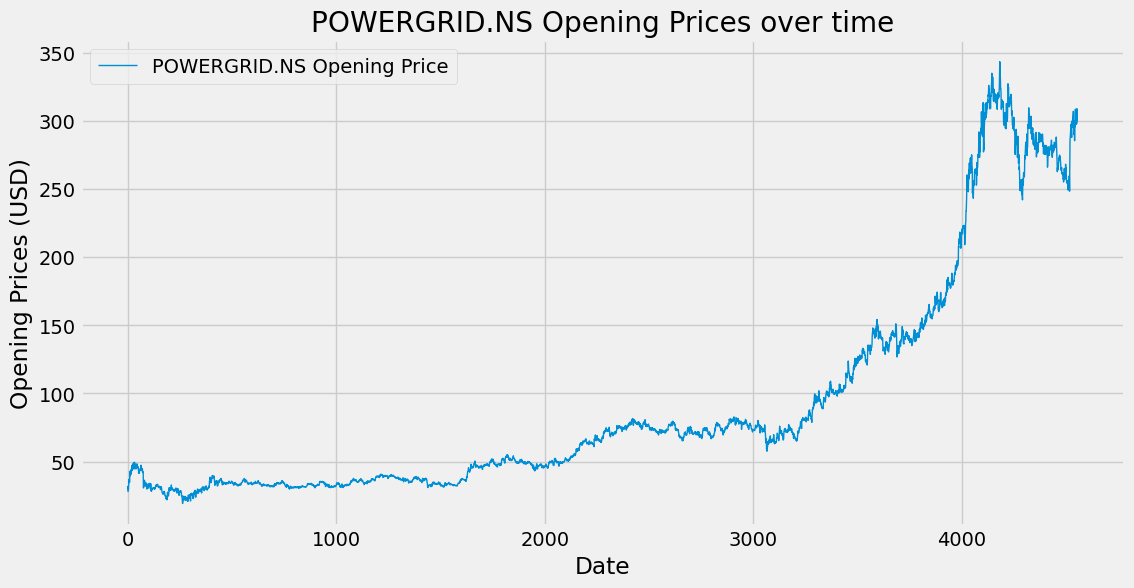

In [20]:
plt.figure(figsize=(12, 6))
plt.plot(df['Open'], label = f'{stock} Opening Price', linewidth = 1)
plt.title(f'{stock} Opening Prices over time')
plt.xlabel('Date')
plt.ylabel('Opening Prices (USD)')
plt.legend()
plt.show()

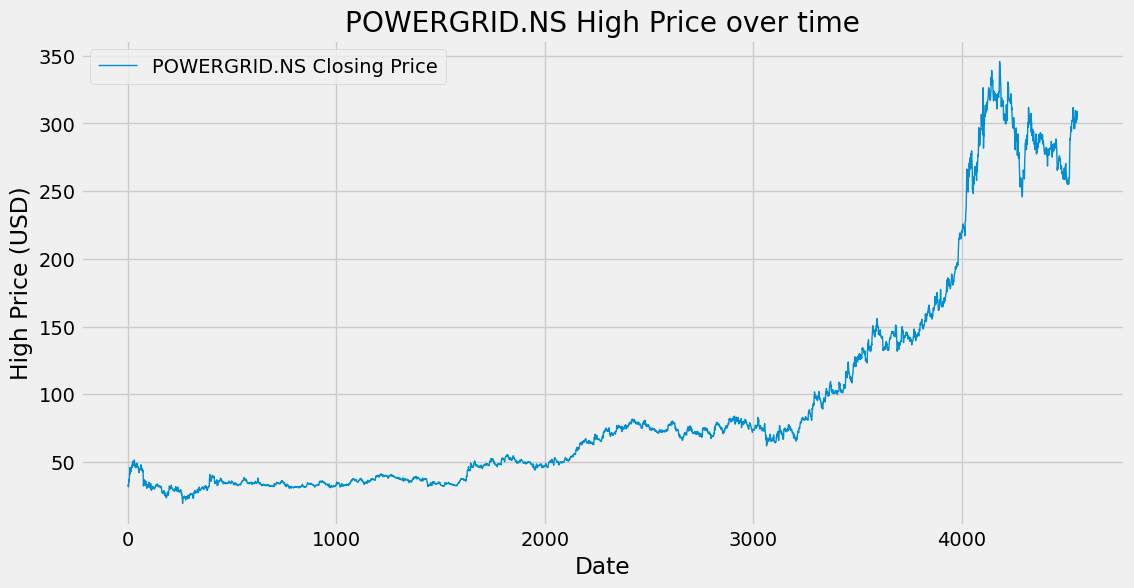

In [21]:
plt.figure(figsize=(12, 6))
plt.plot(df['High'], label = f'{stock} Closing Price', linewidth = 1)
plt.title(f'{stock} High Price over time')
plt.xlabel('Date')
plt.ylabel('High Price (USD)')
plt.legend()
plt.show()

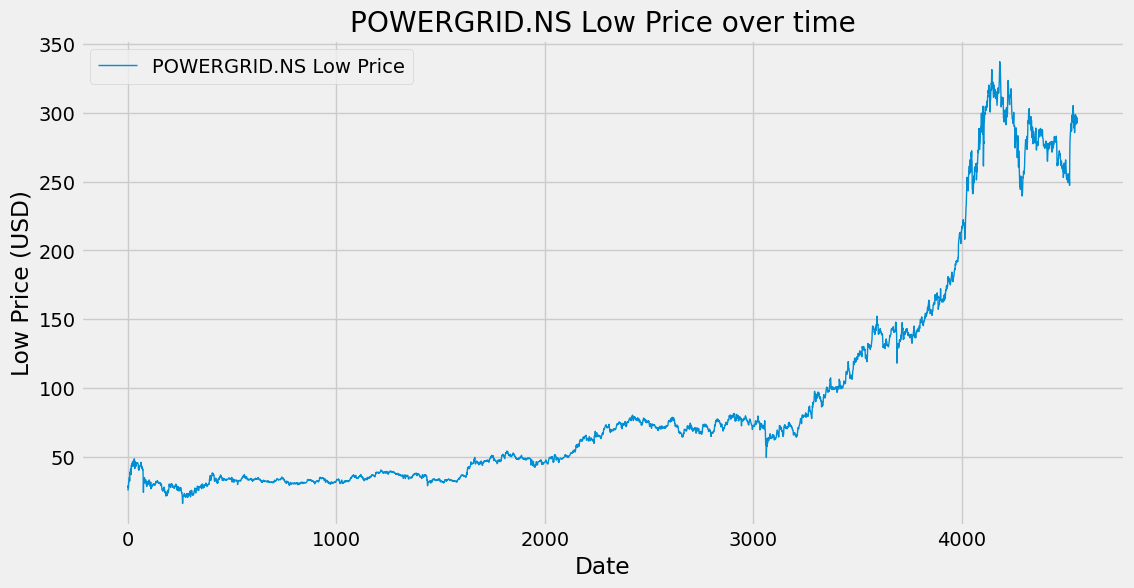

In [22]:
plt.figure(figsize=(12, 6))
plt.plot(df['Low'], label = f'{stock} Low Price', linewidth = 1)
plt.title(f'{stock} Low Price over time')
plt.xlabel('Date')
plt.ylabel('Low Price (USD)')
plt.legend()
plt.show()

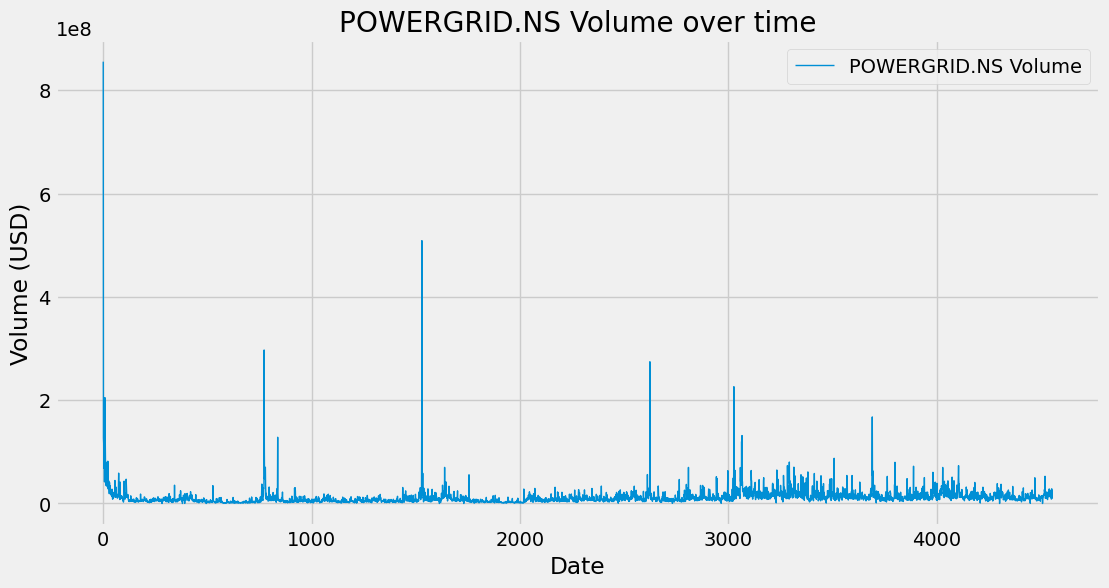

In [23]:
plt.figure(figsize=(12, 6))
plt.plot(df['Volume'], label = f'{stock} Volume', linewidth = 1)
plt.title(f'{stock} Volume over time')
plt.xlabel('Date')
plt.ylabel('Volume (USD)')
plt.legend()
plt.show()

In [24]:
print(df[['Open','High','Low','Close']].head())


Price       Open       High        Low      Close
0      27.579336  33.629592  25.536990  30.896227
1      31.940436  31.940436  29.130291  29.314564
2      29.329932  31.587263  27.748267  31.310856
3      32.124711  32.247560  31.326201  31.602608
4      36.854362  36.854362  31.326209  35.134491


In [25]:
print((df['Open'] == df['Close']).all())
print((df['High'] == df['Close']).all())
print((df['Low'] == df['Close']).all())


False
False
False


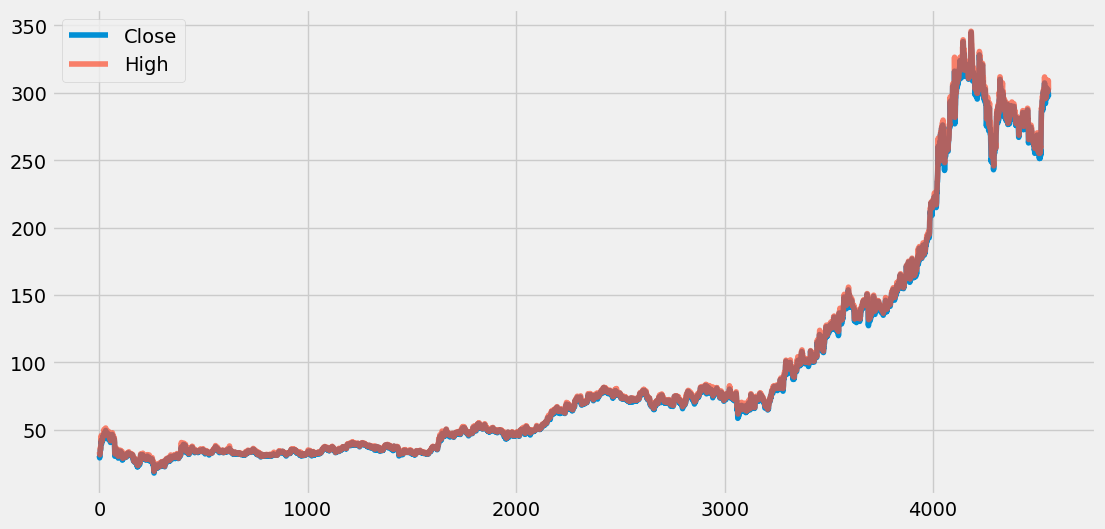

In [26]:
plt.figure(figsize=(12,6))
plt.plot(df['Close'], label='Close')
plt.plot(df['High'], label='High', alpha=0.7)
plt.legend()
plt.show()

In [27]:
# Moving Average : Moving average pichhle kuch dino ke prices ka average hota hai jo price 
# ke trend ko samajhne me madad karta hai !!!
# [10,20,30,40,50,60,70,80,90]
# moving average for last 5 days -> null null null null 30.0 40.0 50.0 

temp_data = [10,20,30,40,50,60,70,80,90]
print(sum(temp_data[2:7])/5)

50.0


In [28]:
import pandas as pd 
df01 = pd.DataFrame(temp_data)

In [29]:
df01.rolling(5).mean()

,0
0,NaN
1,NaN
2,NaN
3,NaN
4,30.0
5,40.0
6,50.0
7,60.0
8,70.0


In [30]:
# moving average value ma100, ma200 
ma100 = df.Close.rolling(100).mean()

In [31]:
ma100 

0              NaN
1              NaN
2              NaN
3              NaN
4              NaN
           ...    
4550    274.576729
4551    274.722158
4552    274.939817
4553    275.057426
4554    275.194978
Name: Close, Length: 4555, dtype: float64

In [32]:
ma200 = df.Close.rolling(200).mean()
ma200

0              NaN
1              NaN
2              NaN
3              NaN
4              NaN
           ...    
4550    277.717543
4551    277.809907
4552    277.923318
4553    277.993632
4554    278.047691
Name: Close, Length: 4555, dtype: float64

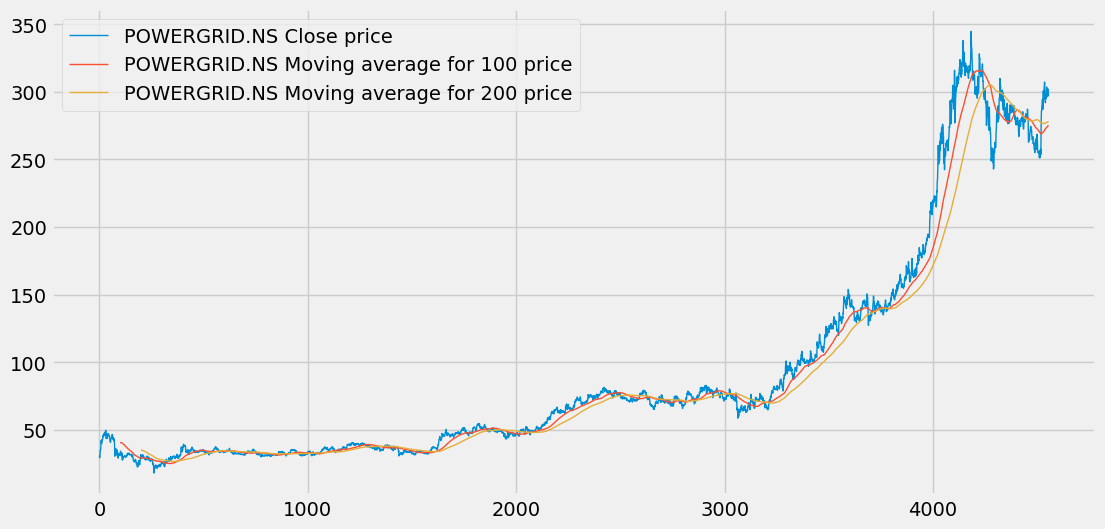

In [33]:
plt.figure(figsize=(12, 6))
plt.plot(df.Close, label = f'{stock} Close price', linewidth = 1)
plt.plot(ma100, label = f'{stock} Moving average for 100 price', linewidth = 1)
plt.plot(ma200, label = f'{stock} Moving average for 200 price', linewidth = 1)
plt.legend()
plt.show()



In [34]:
# exponential moving average "ema"
ema100 = df.Close.ewm(span=100, adjust=False).mean()

In [35]:
ema200 = df.Close.ewm(span=100, adjust=False).mean()

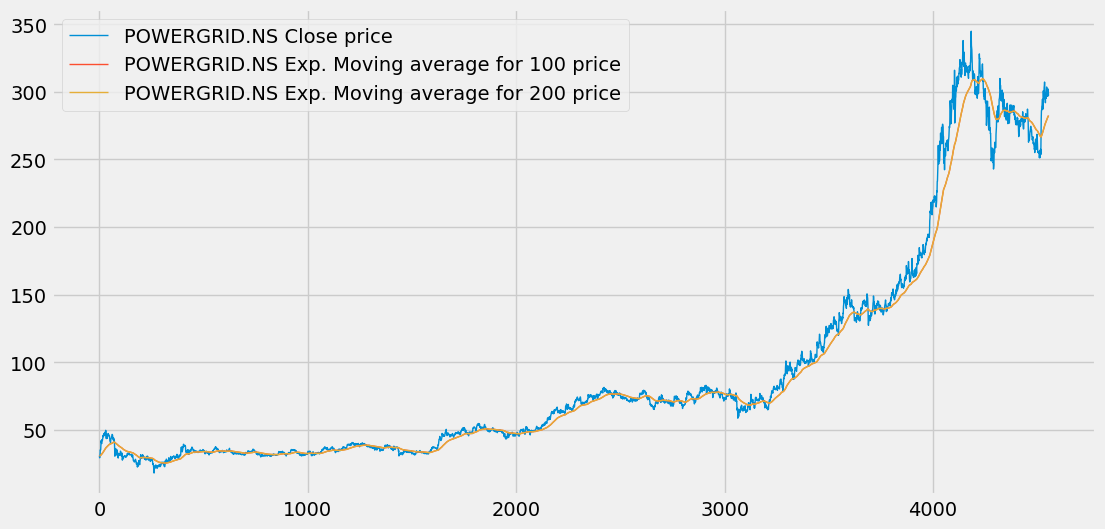

In [36]:
plt.figure(figsize=(12, 6))
plt.plot(df.Close, label = f'{stock} Close price', linewidth = 1)
plt.plot(ema100, label = f'{stock} Exp. Moving average for 100 price', linewidth = 1)
plt.plot(ema200, label = f'{stock} Exp. Moving average for 200 price', linewidth = 1)
plt.legend()
plt.show()

In [37]:
# suppose we want to predict stocks for next 30 days, so we are doing here the prediction
# when the prediction has to be done, LSTM comes to the scene
# we are using LSTM over RNN kyu ki RNN is comparatively slow, and over flows over time
# if more data has to be stored ; RNN have less memory cells too

In [38]:
# Training and testing

data_training = pd.DataFrame(df['Close'][0:int(len(df)*0.70)])
data_testing = pd.DataFrame(df['Close'][int(len(df)*0.70): int (len(df))])

In [39]:
data_training.shape

(3188, 1)

In [40]:
data_testing.shape

(1367, 1)

In [41]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))

In [42]:
data_training_array = scaler.fit_transform(data_training)

In [43]:
data_training_array

array([[0.19808594],
       [0.17371819],
       [0.20447388],
       ...,
       [0.82123778],
       [0.83277436],
       [0.82412166]], shape=(3188, 1))

In [44]:
x_train = [] #feature
y_train = [] #target

for i in range(100, data_training_array.shape[0]):
    x_train.append(data_training_array[i-100:i])
    y_train.append(data_training_array[i, 0])

x_train, y_train = np.array(x_train), np.array(y_train)

In [45]:
x_train.shape

(3088, 100, 1)

In [46]:
# Model Building

from keras.layers import Dense, Dropout, LSTM, Input
from keras.models import Sequential

c:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning:

In the future `np.object` will be defined as the corresponding NumPy scalar.



In [47]:
# LSTM requires input data in 3D format: (batch_size, time_steps, features).
# LSTM looks at past days (time_steps), 
# learns patterns from features (units), and predicts future stock prices.

In [48]:

model = Sequential()

model.add(Input(shape=(x_train.shape[1], 1)))

model.add(LSTM(50, activation='relu', return_sequences=True))
model.add(Dropout(0.2))

model.add(LSTM(60, activation='relu', return_sequences=True))
model.add(Dropout(0.3))

model.add(LSTM(80, activation='relu', return_sequences=True))
model.add(Dropout(0.4))

model.add(LSTM(120, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(1))


In [49]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 50)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100, 60)        │        26,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100, 60)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 100, 80)        │        45,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100, 80)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 120)            │        96,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           121 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 178,761 (698.29 KB)

 Trainable params: 178,761 (698.29 KB)

 Non-trainable params: 0 (0.00 B)

In [50]:
model.compile(optimizer='adam', loss='mean_squared_error') 
model.fit(x_train, y_train, epochs=50)

Epoch 1/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 344s 4s/step - loss: 0.0353
Epoch 2/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 16s 163ms/step - loss: 0.0091
Epoch 3/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 18s 186ms/step - loss: 0.0085
Epoch 4/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 16s 168ms/step - loss: 0.0072
Epoch 5/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 16s 163ms/step - loss: 0.0070
Epoch 6/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 17s 178ms/step - loss: 0.0078
Epoch 7/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 22s 224ms/step - loss: 0.0061
Epoch 8/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 21s 215ms/step - loss: 0.0061
Epoch 9/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 24s 247ms/step - loss: 0.0055
Epoch 10/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 21s 219ms/step - loss: 0.0053
Epoch 11/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 19s 199ms/step - loss: 0.0049
Epoch 12/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 20s 203ms/step - loss: 0.0046
Epoch 13/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 19s 194ms/step - loss: 0.0043
Epoch 14/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 21s 211ms/step - loss: 0.0043
Epoch 15/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 1269s 

In [51]:
past_100_days = data_training.tail(100)

In [52]:
final_df = pd.concat([past_100_days, data_testing], ignore_index=True)

In [53]:
final_df.head()

,Close
0,63.930515
1,64.276207
2,65.902939
3,64.682892
4,66.553627


In [54]:
input_data = scaler.fit_transform(final_df)

In [55]:
x_test = [] #feature
y_test = [] #target

for i in range(100, input_data.shape[0]):
    x_test.append(input_data[i-100:i])
    y_test.append(input_data[i, 0])

x_test, y_test = np.array(x_test), np.array(y_test)

In [56]:
x_test.shape

(1367, 100, 1)

In [57]:
y_predicted = model.predict(x_test)

43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step


In [58]:
y_predicted.shape

(1367, 1)

In [59]:
scaler.scale_

array([0.00354596])

In [60]:
scaler_factor = 1 / 0.00345503
y_predicted = y_predicted * scaler_factor
y_test = y_test * scaler_factor

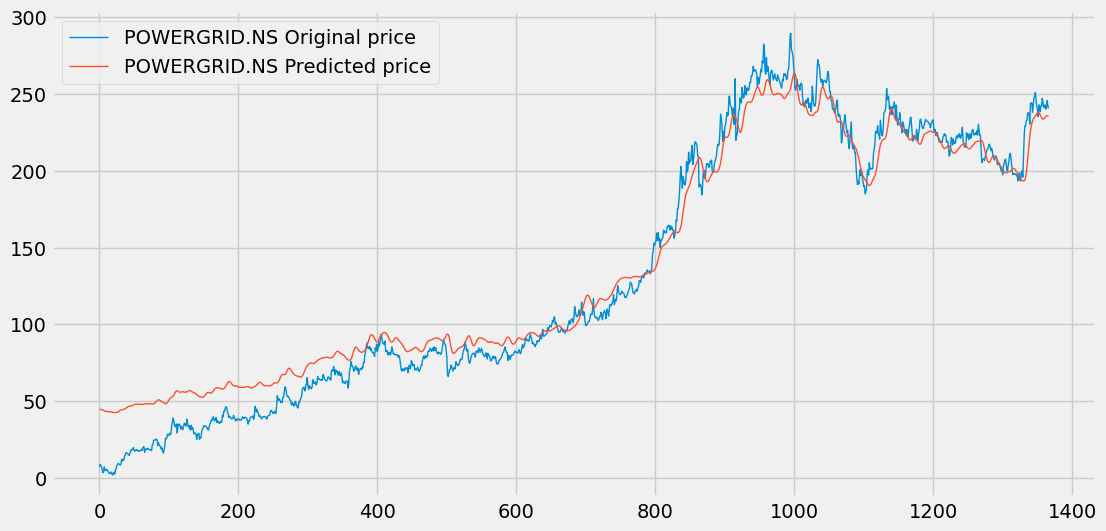

In [61]:
plt.figure(figsize=(12, 6))
plt.plot(y_test, label = f'{stock} Original price', linewidth = 1)
plt.plot(y_predicted, label = f'{stock} Predicted price', linewidth = 1)
plt.legend()
plt.show()

In [62]:
model.save('stock_dl_model.keras')
